# Spot Trace Scenario Ranking (Goodness Score)

Higher score = better scenario for experiments.

**Scoring:**
- `integral`: sum of availability across all types and timesteps (base score)
- `norm_events`: `num_events / max_events` → [0, 1]
- `norm_magnitude`: `total_magnitude / max_magnitude` → [0, 1]
- `score = integral / (1 + norm_events + norm_magnitude)`

**Properties:**
- no events → score = integral (no penalty)
- max events & magnitude → score = integral/3 (heavier penalty)

**Filters:**
- `integral > 0`: exclude windows with zero availability
- `penalty > 0`: exclude windows with no events (just cheap on-demand)

**Interpretation:**
- **Top ranks**: high availability, few/small interruptions (mild)
- **Bottom ranks**: low availability, many/large interruptions (challenging)

In [19]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HETERO_CONFIG = {
    'g6.12xlarge': 3,
    'g5.12xlarge': 2,
    'g6e.xlarge': 4
}

WINDOW_SIZE = 50  # minutes
WINDOW_STEP = 5   # minutes

INSTANCE_ORDER = ['g5.12xlarge', 'g6.12xlarge', 'g6e.xlarge']
LINESTYLES = ['-', '--', '-.']
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

In [20]:
def load_data(start_date, end_date):
    """
    Load and preprocess spot availability data for a date range.
    
    Args:
        start_date: str, e.g. '2026-03-13'
        end_date: str, e.g. '2026-03-19' (inclusive)
    
    Returns:
        avail_df: DataFrame with 5-min resampled availability, capped at needed count
    """
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    
    all_csvs = sorted(glob.glob('./2026-03-*.csv'))
    csv_files = [f for f in all_csvs
                 if start <= pd.Timestamp(os.path.basename(f).replace('.csv', '')) <= end]
    
    if not csv_files:
        raise ValueError(f'No CSV files found for {start_date} ~ {end_date}')
    
    print(f'Loading {len(csv_files)} files: {start_date} ~ {end_date}')
    
    instance_types = list(HETERO_CONFIG.keys())
    df_raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
    df_raw = df_raw[df_raw['InstanceType'].isin(instance_types)].copy()
    df_raw['RequestDateTime'] = pd.to_datetime(df_raw['RequestDateTime'])
    df_raw = df_raw.sort_values('RequestDateTime').reset_index(drop=True)
    
    availability_series = {}
    for itype in instance_types:
        needed = HETERO_CONFIG[itype]
        subset = df_raw[df_raw['InstanceType'] == itype][['RequestDateTime', 'Success']].copy()
        subset = subset.set_index('RequestDateTime').sort_index()
        subset = subset[~subset.index.duplicated(keep='last')]
        subset.index = subset.index.floor('5min')
        subset_resampled = subset.resample('5min').ffill()
        subset_resampled['availability'] = subset_resampled['Success'].clip(upper=needed)
        availability_series[itype] = subset_resampled['availability']
    
    avail_df = pd.DataFrame(availability_series).dropna()
    print(f'  Timeline: {avail_df.index.min()} ~ {avail_df.index.max()} ({len(avail_df)} points)')
    return avail_df

In [21]:
def evaluate_window(window_df):
    """
    Evaluate a 50-min window.
    Returns raw metrics (integral, num_events, total_magnitude).
    Score is computed later after normalization across all windows.
    """
    if len(window_df) < 4:
        return None
    
    # Integral: sum of all availability values
    integral = float(window_df.sum().sum())
    
    # Events/magnitude (exclude last transition at window_end)
    diffs = window_df.diff().iloc[1:]
    diffs_internal = diffs.iloc[:-1]
    abs_diffs = diffs_internal.abs()
    
    num_events = int((abs_diffs > 0).any(axis=1).sum())
    total_magnitude = int(abs_diffs.sum().sum())
    
    return {
        'integral': integral,
        'num_events': num_events,
        'total_magnitude': total_magnitude,
    }

In [22]:
def run_analysis(avail_df):
    """
    Run sliding window analysis with goodness scoring.
    score = integral / (1 + norm_events + norm_magnitude)
    """
    results = []
    ws_td = pd.Timedelta(minutes=WINDOW_SIZE)
    step_td = pd.Timedelta(minutes=WINDOW_STEP)
    
    t = avail_df.index.min()
    t_end = avail_df.index.max()
    
    while t + ws_td <= t_end:
        window_data = avail_df.loc[t:t + ws_td]
        metrics = evaluate_window(window_data)
        if metrics is not None:
            metrics['window_start'] = t
            metrics['window_end'] = t + ws_td
            results.append(metrics)
        t += step_td
    
    results_df = pd.DataFrame(results)
    total = len(results_df)
    
    # Filter out integral=0 windows (meaningless)
    results_df = results_df[results_df['integral'] > 0].copy()
    after_integral = len(results_df)
    print(f'  Windows with integral > 0: {after_integral}/{total} ({after_integral/total*100:.1f}%)')
    
    # Normalize penalties using max values across all windows
    max_events = results_df['num_events'].max()
    max_magnitude = results_df['total_magnitude'].max()
    print(f'  max_events={max_events}, max_magnitude={max_magnitude}')
    
    norm_events = results_df['num_events'] / max_events if max_events > 0 else 0
    norm_magnitude = results_df['total_magnitude'] / max_magnitude if max_magnitude > 0 else 0
    results_df['norm_events'] = norm_events
    results_df['norm_magnitude'] = norm_magnitude
    results_df['score'] = results_df['integral'] / (1 + norm_events + norm_magnitude)
    
    # Filter out penalty=0 windows (no events = just cheap on-demand, not interesting)
    has_events = int(((norm_events + norm_magnitude) > 0).sum())
    print(f'  Windows with events: {has_events}/{after_integral} ({has_events/after_integral*100:.1f}%)')
    results_df = results_df[(norm_events + norm_magnitude) > 0].copy()
    
    # Sort by score descending (higher = better)
    results_df = results_df.sort_values('score', ascending=False).reset_index(drop=True)
    results_df.index += 1
    results_df.index.name = 'Rank'
    
    print(f'  Final: {len(results_df)} windows')
    print(f'  Score range: {results_df["score"].min():.1f} ~ {results_df["score"].max():.1f}')
    return results_df

In [23]:
def plot_scenario_grid(scenarios_df, avail_df, title, ncols=4):
    """Plot a grid of scenario trace figures with real timestamps on x-axis."""
    n = len(scenarios_df)
    if n == 0:
        print(f'{title}: no scenarios to plot')
        return
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)

    for i, (rank, row) in enumerate(scenarios_df.iterrows()):
        ax = axes[i // ncols][i % ncols]
        ws, we = row['window_start'], row['window_end']
        window_data = avail_df.loc[ws:we]

        for j, itype in enumerate(INSTANCE_ORDER):
            ax.plot(window_data.index, window_data[itype],
                    label=itype, color=COLORS[j],
                    linestyle=LINESTYLES[j], linewidth=2,
                    drawstyle='steps-post', marker='o', markersize=2)

        ax.set_title(f'Rank #{rank}  (score={row["score"]:.0f})', fontsize=10, fontweight='bold')
        ax.set_xlim(ws, we)
        ax.set_ylim(-0.2, max(HETERO_CONFIG.values()) + 0.5)
        ax.set_yticks(range(0, max(HETERO_CONFIG.values()) + 1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
        ax.set_xlabel(ws.strftime('%m/%d'), fontsize=8)
        ax.set_ylabel('Availability', fontsize=8)
        ax.tick_params(labelsize=7)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for i in range(n, nrows * ncols):
        axes[i // ncols][i % ncols].set_visible(False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()

In [24]:
def show_results(results_df, avail_df):
    """Display tables and trace plots for top-12 (mild), median-12, bottom-12 (challenging)."""
    display_cols = ['window_start', 'window_end', 'integral', 'num_events', 'total_magnitude', 'norm_events', 'norm_magnitude', 'score']
    
    top12 = results_df.head(12)
    
    mid = len(results_df) // 2
    mid_start = max(0, mid - 6)
    median12 = results_df.iloc[mid_start:mid_start + 12]
    
    bottom12 = results_df.tail(12)
    
    print(f'=== Top-12 Mild (Rank 1~{len(top12)}) ===')
    display(top12[display_cols])
    print(f'\n=== Median-12 ===')
    display(median12[display_cols])
    print(f'\n=== Bottom-12 Challenging ===')
    display(bottom12[display_cols])
    
    plot_scenario_grid(top12, avail_df, 'Top-12 Mild')
    plot_scenario_grid(median12, avail_df, 'Median-12')
    plot_scenario_grid(bottom12, avail_df, 'Bottom-12 Challenging')
    
    # Summary
    print(f'\n=== Summary ===')
    print(f'Total scenarios: {len(results_df)}')
    print(results_df[['integral', 'num_events', 'total_magnitude', 'norm_events', 'norm_magnitude', 'score']].describe())

In [25]:
def analyze(start_date, end_date):
    """
    Full pipeline: load -> analyze -> display results.
    
    Args:
        start_date: str, e.g. '2026-03-13'
        end_date: str, e.g. '2026-03-18' (inclusive)
    
    Returns:
        results_df, avail_df
    """
    print(f'\n{"=" * 60}')
    print(f'Analyzing: {start_date} ~ {end_date}')
    print(f'{"=" * 60}')
    
    avail_df = load_data(start_date, end_date)
    results_df = run_analysis(avail_df)
    show_results(results_df, avail_df)
    return results_df, avail_df


Analyzing: 2026-03-13 ~ 2026-03-18
Loading 6 files: 2026-03-13 ~ 2026-03-18
  Timeline: 2026-03-13 01:20:00 ~ 2026-03-18 23:50:00 (1711 points)
  Windows with integral > 0: 1683/1701 (98.9%)
  max_events=5, max_magnitude=24
  Windows with events: 1013/1683 (60.2%)
  Final: 1013 windows
  Score range: 0.8 ~ 78.9
=== Top-12 Mild (Rank 1~12) ===


,window_start,window_end,integral,num_events,total_magnitude,norm_events,norm_magnitude,score
Rank,,,,,,,,
1,2026-03-15 15:25:00,2026-03-15 16:15:00,98.0,1,1,0.2,0.041667,78.926174
2,2026-03-15 11:55:00,2026-03-15 12:45:00,98.0,1,1,0.2,0.041667,78.926174
3,2026-03-15 11:50:00,2026-03-15 12:40:00,97.0,1,1,0.2,0.041667,78.120805
4,2026-03-15 15:20:00,2026-03-15 16:10:00,97.0,1,1,0.2,0.041667,78.120805
5,2026-03-15 21:10:00,2026-03-15 22:00:00,97.0,1,1,0.2,0.041667,78.120805
6,2026-03-15 21:05:00,2026-03-15 21:55:00,97.0,1,1,0.2,0.041667,78.120805
7,2026-03-15 07:55:00,2026-03-15 08:45:00,97.0,1,2,0.2,0.083333,75.584416
8,2026-03-17 08:15:00,2026-03-17 09:05:00,97.0,1,2,0.2,0.083333,75.584416
9,2026-03-15 20:35:00,2026-03-15 21:25:00,97.0,1,2,0.2,0.083333,75.584416



=== Median-12 ===


,window_start,window_end,integral,num_events,total_magnitude,norm_events,norm_magnitude,score
Rank,,,,,,,,
501,2026-03-18 02:15:00,2026-03-18 03:05:00,85.0,5,12,1.0,0.500000,34.000000
502,2026-03-18 02:50:00,2026-03-18 03:40:00,71.0,4,7,0.8,0.291667,33.944223
503,2026-03-14 15:55:00,2026-03-14 16:45:00,53.0,2,4,0.4,0.166667,33.829787
504,2026-03-18 11:10:00,2026-03-18 12:00:00,65.0,3,8,0.6,0.333333,33.620690
505,2026-03-13 19:55:00,2026-03-13 20:45:00,65.0,3,8,0.6,0.333333,33.620690
506,2026-03-13 20:00:00,2026-03-13 20:50:00,65.0,3,8,0.6,0.333333,33.620690
507,2026-03-13 20:05:00,2026-03-13 20:55:00,65.0,3,8,0.6,0.333333,33.620690
508,2026-03-13 20:15:00,2026-03-13 21:05:00,65.0,3,8,0.6,0.333333,33.620690
509,2026-03-13 20:10:00,2026-03-13 21:00:00,65.0,3,8,0.6,0.333333,33.620690



=== Bottom-12 Challenging ===


,window_start,window_end,integral,num_events,total_magnitude,norm_events,norm_magnitude,score
Rank,,,,,,,,
1002,2026-03-18 17:05:00,2026-03-18 17:55:00,3.0,1,1,0.2,0.041667,2.416107
1003,2026-03-18 19:30:00,2026-03-18 20:20:00,4.0,3,3,0.6,0.125000,2.318841
1004,2026-03-18 19:25:00,2026-03-18 20:15:00,4.0,3,3,0.6,0.125000,2.318841
1005,2026-03-18 19:35:00,2026-03-18 20:25:00,4.0,4,4,0.8,0.166667,2.033898
1006,2026-03-18 19:20:00,2026-03-18 20:10:00,3.0,2,2,0.4,0.083333,2.022472
1007,2026-03-18 17:10:00,2026-03-18 18:00:00,2.0,1,1,0.2,0.041667,1.610738
1008,2026-03-18 18:55:00,2026-03-18 19:45:00,2.0,1,1,0.2,0.041667,1.610738
1009,2026-03-18 19:00:00,2026-03-18 19:50:00,2.0,1,1,0.2,0.041667,1.610738
1010,2026-03-18 19:05:00,2026-03-18 19:55:00,2.0,2,2,0.4,0.083333,1.348315


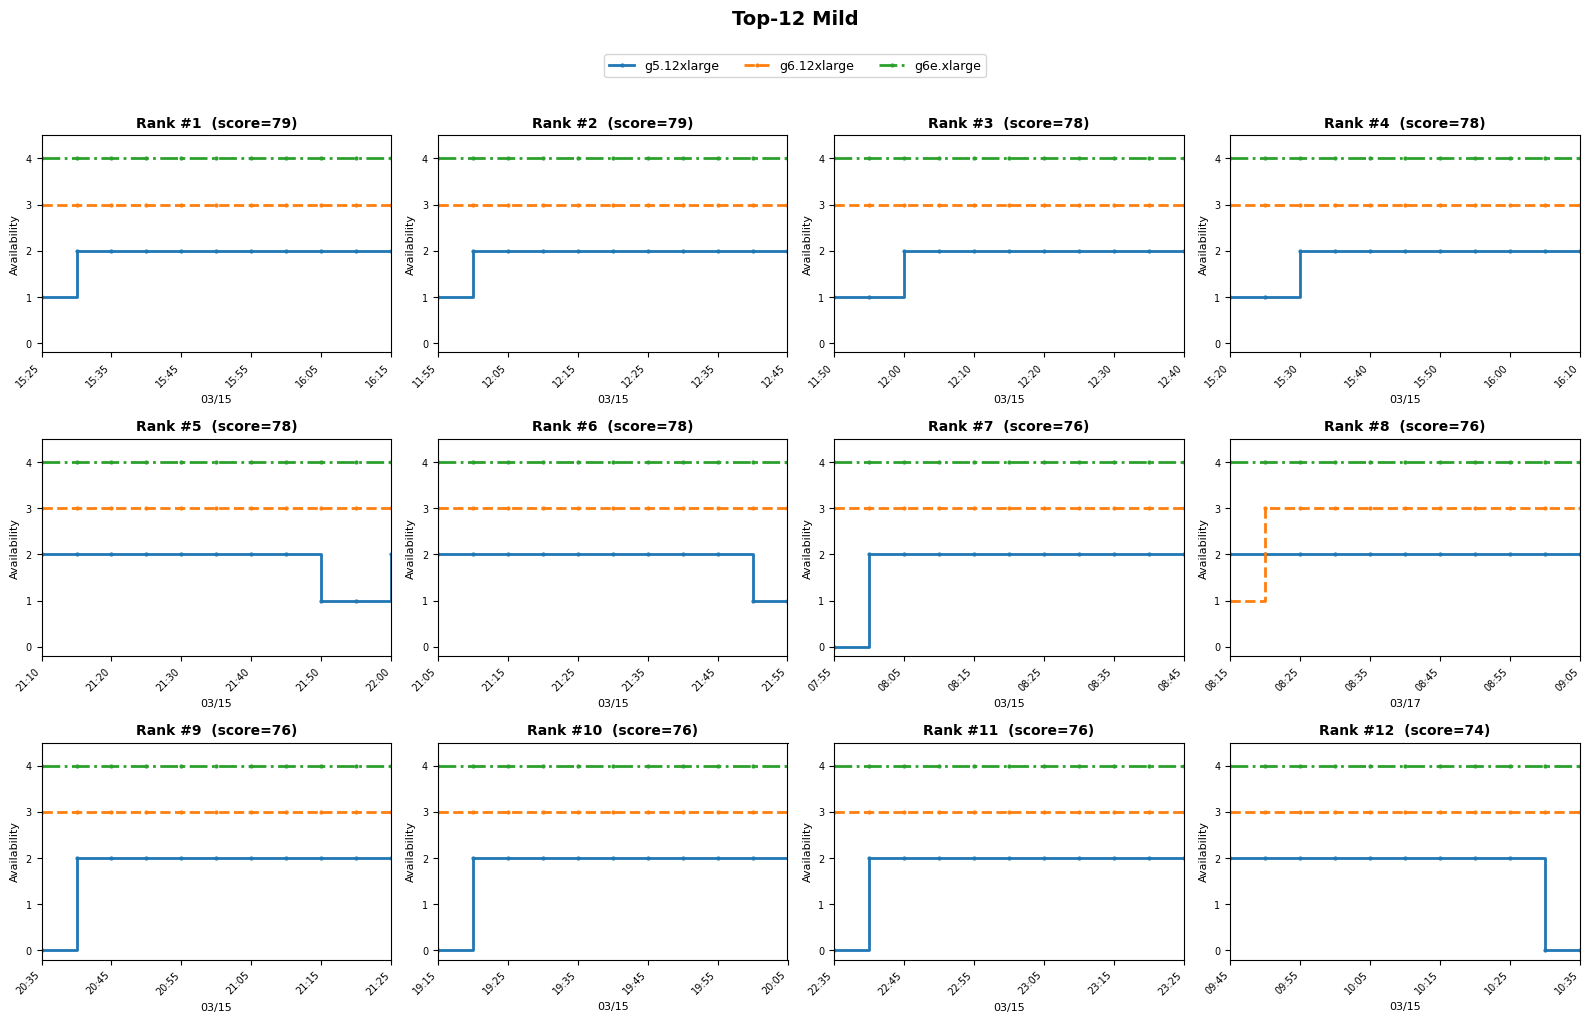

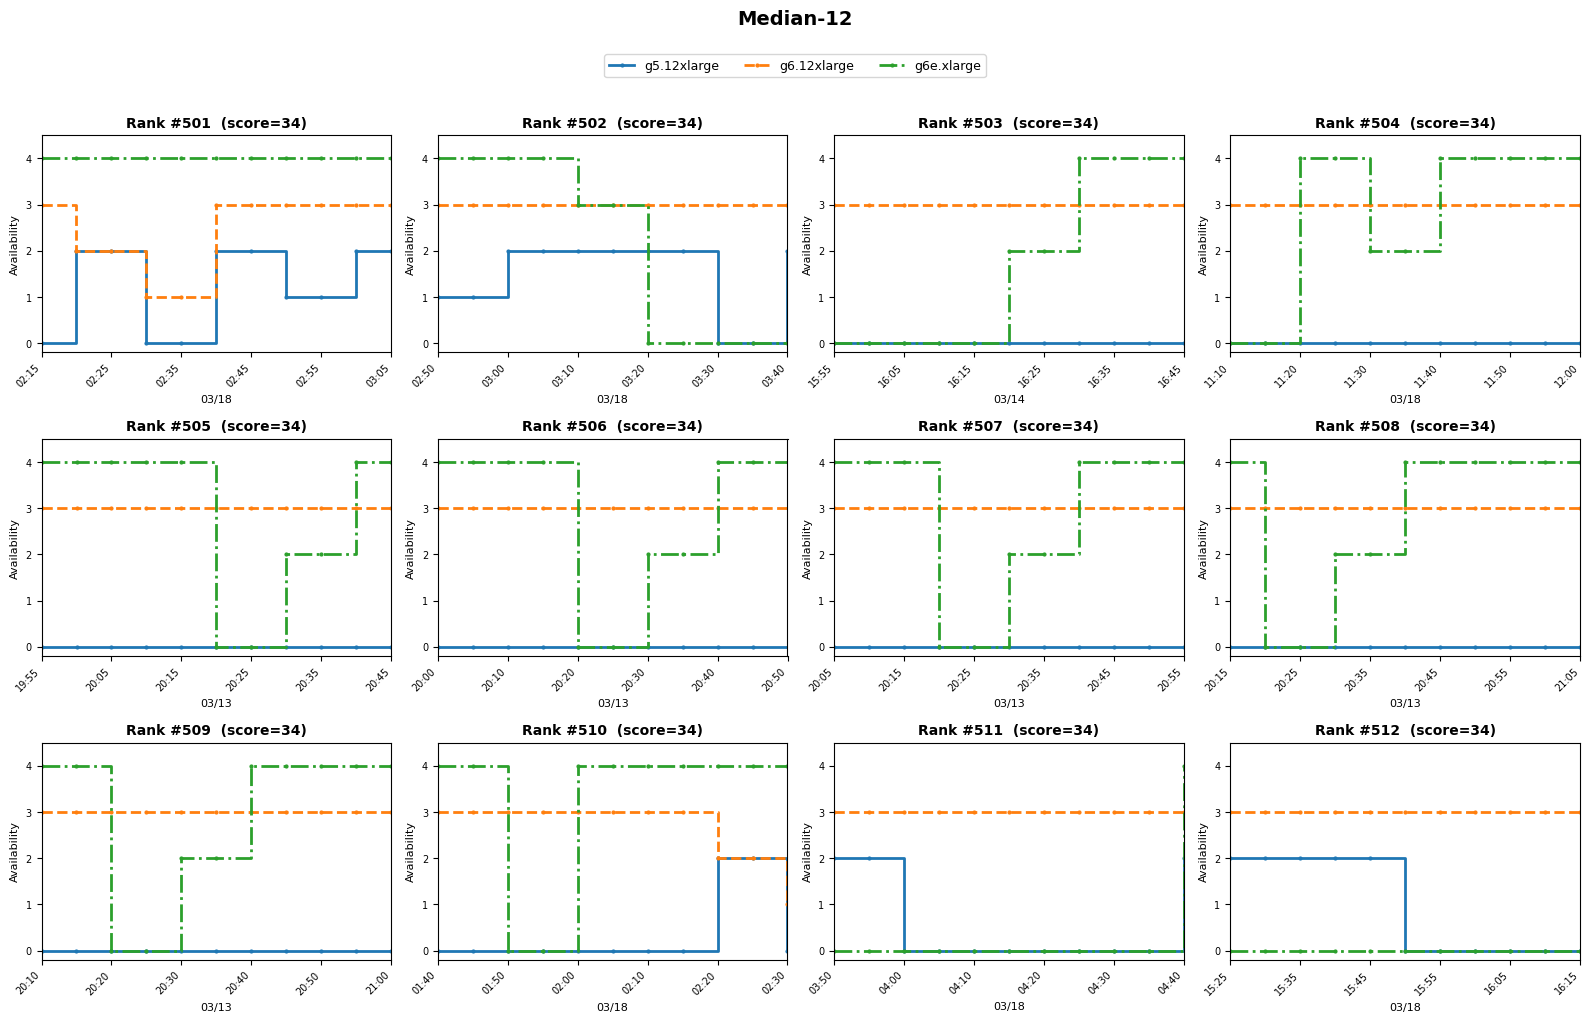

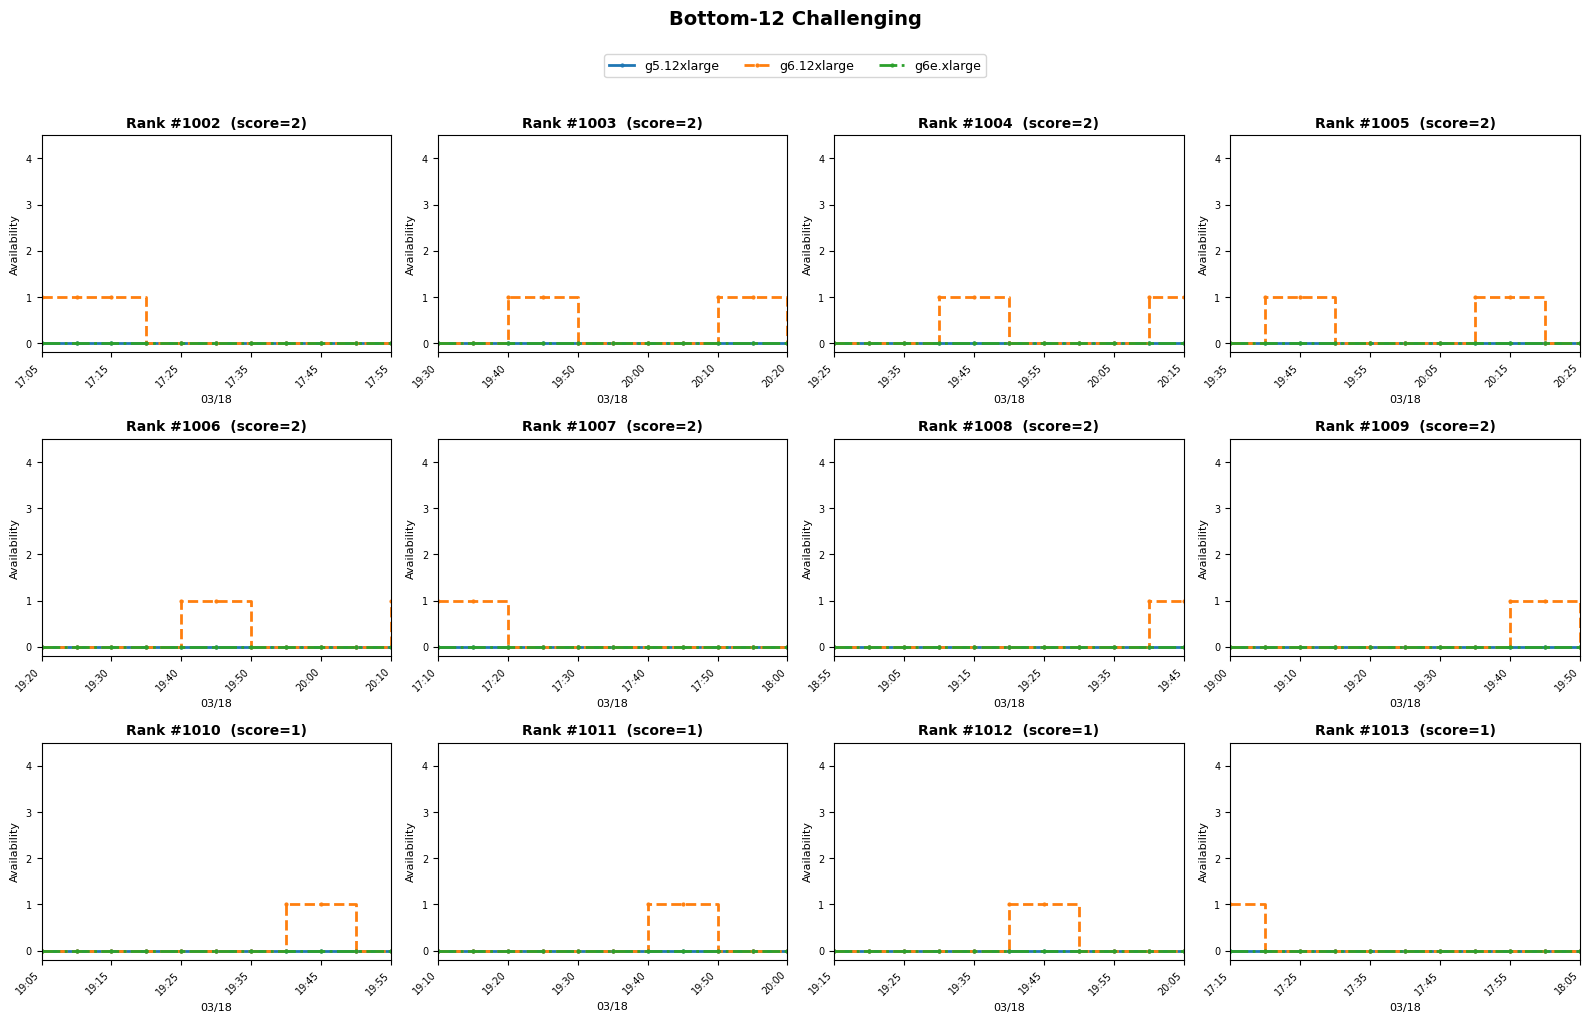


=== Summary ===
Total scenarios: 1013
          integral   num_events  total_magnitude  norm_events  norm_magnitude  \
count  1013.000000  1013.000000      1013.000000  1013.000000     1013.000000   
mean     58.235933     2.446199         5.884501     0.489240        0.245188   
std      25.052171     1.103497         3.997960     0.220699        0.166582   
min       1.000000     1.000000         1.000000     0.200000        0.041667   
25%      41.000000     2.000000         3.000000     0.400000        0.125000   
50%      61.000000     2.000000         4.000000     0.400000        0.166667   
75%      79.000000     3.000000         8.000000     0.600000        0.333333   
max      98.000000     5.000000        24.000000     1.000000        1.000000   

             score  
count  1013.000000  
mean     35.367558  
std      17.919322  
min       0.805369  
25%      22.988506  
50%      33.620690  
75%      49.148936  
max      78.926174  


In [26]:
results_all, avail_all = analyze('2026-03-13', '2026-03-18')

In [27]:
# results_mid, avail_mid = analyze('2026-03-14', '2026-03-16')